NAME: SPOORTHI A
COURSE: ARTIFICIAL INTELLIGENCE
PROJECT NO 1: SENTIMENT ANALYSIS PROJECT USING CNN

In [4]:
# ================================================
# Sentiment Analysis using CNN
# Dataset: IMDB Movie Reviews
# ================================================

# STEP 1 - Import Libraries
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [5]:
# STEP 2 - Set Basic Settings
VOCAB_SIZE = 10000   # use top 10,000 common words
MAX_LEN    = 200     # each review will be 200 words long
EPOCHS     = 10
BATCH_SIZE = 64

In [6]:
# STEP 3 - Load the IMDB Dataset
# 0 = Negative review, 1 = Positive review
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))


Training samples: 25000
Testing samples : 25000


In [7]:
# STEP 4 - Pad the Sequences
# Reviews have different lengths, so we make them all equal length (200)
X_train = pad_sequences(X_train, maxlen=MAX_LEN)
X_test  = pad_sequences(X_test,  maxlen=MAX_LEN)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test :", X_test.shape)



Shape of X_train: (25000, 200)
Shape of X_test : (25000, 200)


In [8]:
# STEP 5 - Build the CNN Model
from tensorflow.keras.layers import Input

model = Sequential()

# Add Input layer first — this tells Keras the exact shape from the start
model.add(Input(shape=(MAX_LEN,)))

# Layer 1: Embedding - converts words (numbers) into vectors
model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=64))

# Layer 2: Conv1D - finds patterns in the text 
model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))

# Layer 3: GlobalMaxPooling - picks the most important feature
model.add(GlobalMaxPooling1D())

# Layer 4: Dense - fully connected layer for learning
model.add(Dense(64, activation='relu'))

# Layer 5: Dropout - randomly turns off some neurons to prevent overfitting
model.add(Dropout(0.5))

# Layer 6: Output layer - gives probability (0 = Negative, 1 = Positive)
model.add(Dense(1, activation='sigmoid'))

# Print model summary
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ (None, 200, 64)             │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 198, 64)             │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d_2               │ (None, 64)                  │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 656,577 (2.50 MB)

 Trainable params: 656,577 (2.50 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# STEP 6 - Compile the Model
model.compile(
    optimizer='adam',           # adam adjusts learning rate automatically
    loss='binary_crossentropy', # used for yes/no (binary) problems
    metrics=['accuracy']
)


In [10]:
# STEP 7 - Train the Model
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,  # use 10% of training data to check progress
    verbose=1
)


Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.7350 - loss: 0.5099 - val_accuracy: 0.8556 - val_loss: 0.3387
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.8938 - loss: 0.2653 - val_accuracy: 0.8912 - val_loss: 0.2743
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9545 - loss: 0.1385 - val_accuracy: 0.8924 - val_loss: 0.2868
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.9867 - loss: 0.0537 - val_accuracy: 0.8808 - val_loss: 0.3593
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.9969 - loss: 0.0185 - val_accuracy: 0.8888 - val_loss: 0.4050
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9990 - loss: 0.0076 - val_accuracy: 0.8912 - val_loss: 0.4444
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9996 - loss: 0.0039 - val_accuracy: 0.8908 - val_loss: 0.4903
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.9998 - loss: 0.0020 - 

In [11]:
# STEP 8 - Evaluate the Model on Test Data
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {round(accuracy * 100, 2)}%")
print(f"Test Loss    : {round(loss, 4)}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8778 - loss: 0.5995
Test Accuracy: 87.78%
Test Loss    : 0.5995


782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step


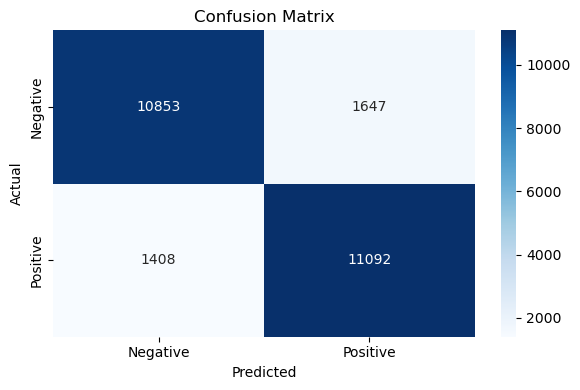

              precision    recall  f1-score   support

    Negative       0.89      0.87      0.88     12500
    Positive       0.87      0.89      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



In [12]:
# STEP 9 - Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)  # convert probabilities to 0 or 1

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot it
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# Report
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))


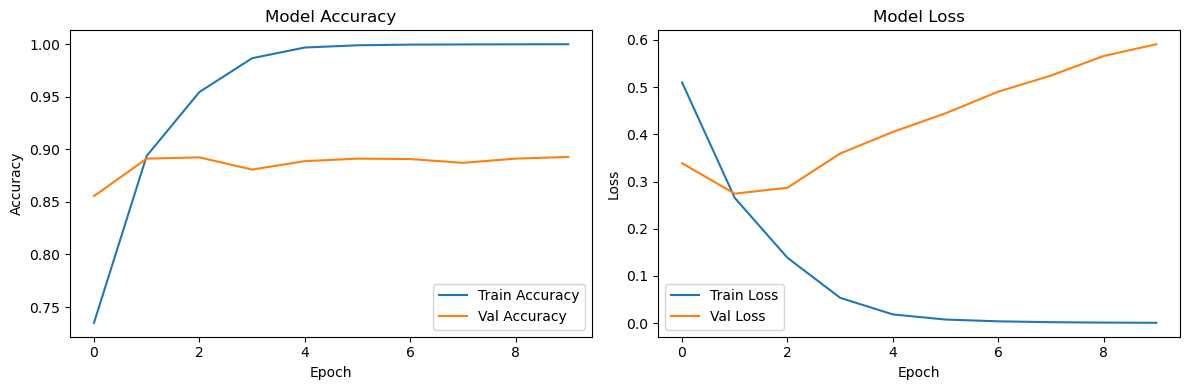

In [13]:
# STEP 10 - Plot Training Results
plt.figure(figsize=(12, 4))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('training_results.png')
plt.show()

In [14]:
# STEP 11 - Test on a Custom Review
word_index = imdb.get_word_index()

def predict_sentiment(review_text):
    # Convert words to numbers
    words = review_text.lower().split()
    encoded = [word_index.get(word, 2) + 3 for word in words]

    # Pad to same length
    padded = pad_sequences([encoded], maxlen=MAX_LEN)

    # Predict
    score = model.predict(padded, verbose=0)[0][0]

    print("\nReview  :", review_text)
    print("Score   :", round(float(score), 4))
    if score >= 0.5:
        print("Result  : POSITIVE REVIEW")
    else:
        print("Result  : NEGATIVE REVIEW")


# Try some sample reviews
predict_sentiment("This movie was amazing! I really loved it.")
predict_sentiment("Terrible film. Boring and a complete waste of time.")
predict_sentiment("It was okay, nothing special but not bad either.")



Review  : This movie was amazing! I really loved it.
Score   : 0.9998
Result  : POSITIVE REVIEW

Review  : Terrible film. Boring and a complete waste of time.
Score   : 0.0
Result  : NEGATIVE REVIEW

Review  : It was okay, nothing special but not bad either.
Score   : 0.0004
Result  : NEGATIVE REVIEW
